
Solving MILP model (This may take a moment due to integer constraints)...

✅ Status: OPTIMAL
💰 Total Objective Value: $2,958,359.50
⏱️ Total Project Makespan: 133.4 Days

--- Project Schedule Snippet ---


,Task_ID,Employee_ID,Start_Day,Finish_Day,Duration_Days
0,P001_T1,EXT_CONTRACTOR,0.000,50.000,50.000
2,P002_T1,E009,0.000,33.375,33.375
6,P003_T2,E008,0.000,50.000,50.000
5,P003_T1,E015,0.000,78.125,78.125
7,P004_T1,E022,0.000,15.625,15.625
9,P004_T3,E003,0.000,125.000,125.000
8,P004_T2,E024,15.625,93.750,78.125
3,P002_T2,E025,33.375,133.375,100.000
4,P002_T3,EXT_CONTRACTOR,33.375,41.750,8.375
1,P001_T2,E018,50.000,128.125,78.125



📊 Saved Corrected Gantt Chart to: 2026-06-16_21-26-28/gantt_chart_fixed.png


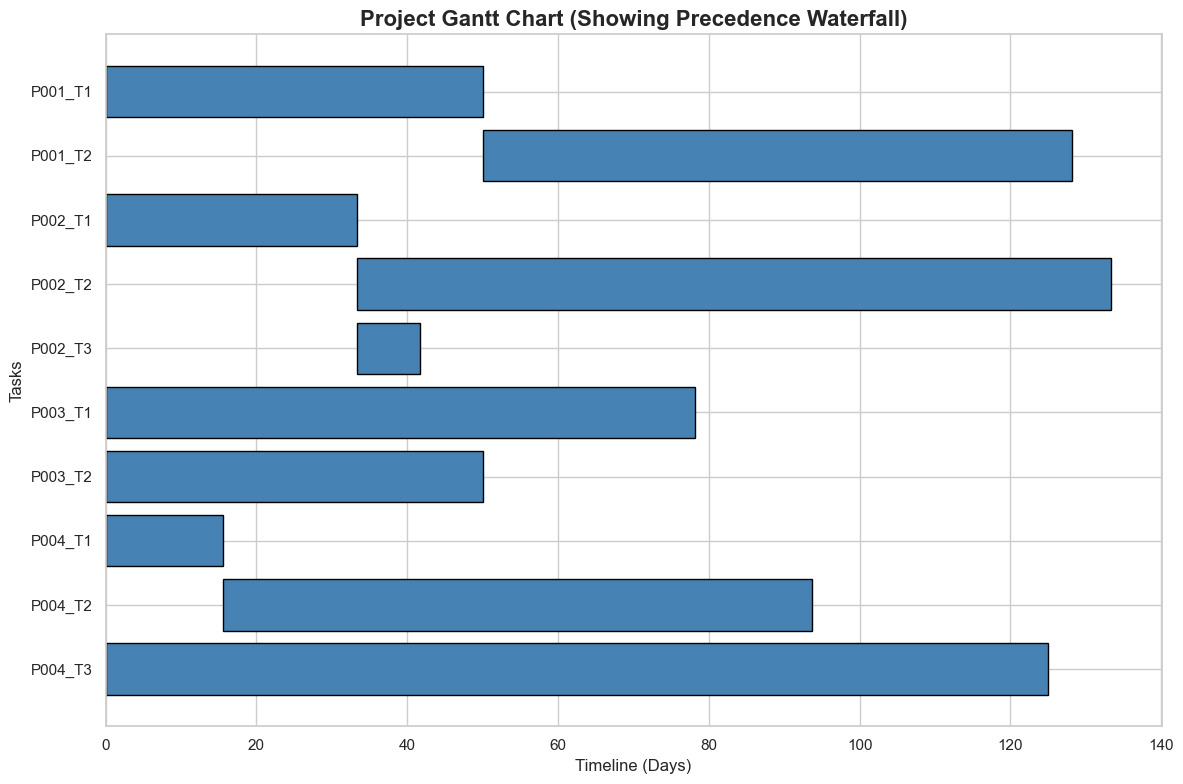

In [1]:
import pandas as pd
import json
from ortools.linear_solver import pywraplp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ==========================================
# 1. LOAD AND PREP DATA
# ==========================================
# UPDATE THIS PATH to your newly generated dataset folder
EXPORT_PATH = '2026-06-16_21-26-28' 

try:
    employees_df = pd.read_csv(f'{EXPORT_PATH}/employees.csv')
    tasks_df = pd.read_csv(f'{EXPORT_PATH}/tasks.csv')
except FileNotFoundError:
    print("Error: Could not find the CSVs.")
    raise

# Custom Parsers
def parse_skill_string(skill_str):
    if pd.isna(skill_str) or not isinstance(skill_str, str):
        return {}
    skill_dict = {}
    for item in skill_str.split('|'):
        if ':' in item:
            skill, level = item.split(':')
            skill_dict[skill.strip()] = int(level.strip())
    return skill_dict

def safe_json_load(val):
    try:
        return json.loads(val)
    except (TypeError, ValueError):
        return []

employees_df['Specific_Skills_Dict'] = employees_df['Specific_Skills'].apply(parse_skill_string)
tasks_df['Req_Dict'] = tasks_df['Skills_Needed'].apply(parse_skill_string) 
tasks_df['Predecessors_List'] = tasks_df['Predecessors'].apply(safe_json_load)

# Safety check for EXT_CONTRACTOR
if 'EXT_CONTRACTOR' not in employees_df['Employee_ID'].values:
    all_required_skills = set()
    for req_dict in tasks_df['Req_Dict']:
        all_required_skills.update(req_dict.keys())
    contractor_skills = {skill: 5 for skill in all_required_skills}
    contractor = pd.DataFrame([{
        'Employee_ID': 'EXT_CONTRACTOR',
        'Specific_Skills_Dict': contractor_skills,
        'Hourly_Cost': 5000,
        'Max_Hours': 999999
    }])
    employees_df = pd.concat([employees_df, contractor], ignore_index=True)


# ==========================================
# 2. VALID PAIRS & BOTTLENECK RHO (Soft Constraint)
# ==========================================
def calculate_skill_rho(emp_level, task_level):
    if emp_level == 0: return 0.8  
    elif emp_level == task_level: return 1.0  
    elif emp_level > task_level: return 1.5  
    else: return 0.5  

valid_pairs = []
rho_dict = {} 

for _, emp in employees_df.iterrows():
    emp_skills = emp['Specific_Skills_Dict']
    for _, task in tasks_df.iterrows():
        task_reqs = task['Req_Dict']
        skill_rhos = []
        missing_skills_count = 0
        
        for skill, req_level in task_reqs.items():
            emp_level = emp_skills.get(skill, 0)
            if emp_level == 0: missing_skills_count += 1
            skill_rhos.append(calculate_skill_rho(emp_level, req_level))
        
        # Must have at least one relevant skill
        if missing_skills_count < len(task_reqs):
            overall_rho = min(skill_rhos)
            pair = (emp['Employee_ID'], task['Task_ID'])
            valid_pairs.append(pair)
            rho_dict[pair] = overall_rho


# ==========================================
# 3. BUILD THE MILP SOLVER (Phase 4: Time Edition)
# ==========================================
solver = pywraplp.Solver.CreateSolver('SCIP')

# --- VARIABLES ---
x = {} # Integer: Work hours
y = {} # Binary: Context switch assignment
M = 2080 
TAU_PENALTY = 20 

for (i, j) in valid_pairs:
    x[(i, j)] = solver.IntVar(0, solver.infinity(), f'x_{i}_{j}')
    y[(i, j)] = solver.BoolVar(f'y_{i}_{j}') 

# Time Variables (Continuous Days)
S = {} # Start Time
F = {} # Finish Time
for j in tasks_df['Task_ID']:
    S[j] = solver.NumVar(0, solver.infinity(), f'Start_{j}')
    F[j] = solver.NumVar(0, solver.infinity(), f'Finish_{j}')

C_max = solver.NumVar(0, solver.infinity(), 'Makespan') 

# --- CORE CONSTRAINTS ---
# 1. Big-M Linking: x_ij - M * y_ij <= 0
for (i, j) in valid_pairs:
    constraint = solver.Constraint(-solver.infinity(), 0, f"BigM_{i}_{j}")
    constraint.SetCoefficient(x[(i, j)], 1)
    constraint.SetCoefficient(y[(i, j)], -M)

# 2. Demand Satisfaction (Using Bottleneck Rho)
demand_dict = tasks_df.set_index('Task_ID')['Hours_Needed'].to_dict()
for j in tasks_df['Task_ID']:
    capable_employees = [i for (i, t_id) in valid_pairs if t_id == j]
    constraint = solver.Constraint(float(demand_dict[j]), solver.infinity(), f"Demand_{j}")
    for i in capable_employees:
        constraint.SetCoefficient(x[(i, j)], float(rho_dict[(i, j)]))

# 3. Capacity Limit (Work + Setup)
cap_dict = employees_df.set_index('Employee_ID')['Max_Hours'].to_dict()
for i in employees_df['Employee_ID']:
    assigned_tasks = [j for (e_id, j) in valid_pairs if e_id == i]
    constraint = solver.Constraint(0, float(cap_dict[i]), f"Capacity_{i}")
    for j in assigned_tasks:
        constraint.SetCoefficient(x[(i, j)], 1)
        constraint.SetCoefficient(y[(i, j)], TAU_PENALTY)

# --- NEW TIME CONSTRAINTS ---
# 4. Duration: Finish - Start >= Sum(Work Hours / 8)
for j in tasks_df['Task_ID']:
    capable_employees = [i for (i, t_id) in valid_pairs if t_id == j]
    constraint = solver.Constraint(0, solver.infinity(), f"Duration_{j}")
    constraint.SetCoefficient(F[j], 1)
    constraint.SetCoefficient(S[j], -1)
    for i in capable_employees:
        constraint.SetCoefficient(x[(i, j)], -0.125) # 1/8 hours per day

# 5. Precedence: Start_j >= Finish_p
for _, task in tasks_df.iterrows():
    j = task['Task_ID']
    predecessors = task['Predecessors_List']
    for p in predecessors:
        constraint = solver.Constraint(0, solver.infinity(), f"Precedence_{p}_to_{j}")
        constraint.SetCoefficient(S[j], 1)
        constraint.SetCoefficient(F[p], -1)

# 6. Makespan Tracker: C_max >= Finish_j
for j in tasks_df['Task_ID']:
    constraint = solver.Constraint(0, solver.infinity(), f"Makespan_{j}")
    constraint.SetCoefficient(C_max, 1)
    constraint.SetCoefficient(F[j], -1)

# --- OBJECTIVE FUNCTION ---
cost_dict = employees_df.set_index('Employee_ID')['Hourly_Cost'].to_dict()
objective = solver.Objective()

# Financial Cost (Wages + Setup)
for (i, j) in valid_pairs:
    wage = float(cost_dict[i])
    objective.SetCoefficient(x[(i, j)], wage)
    objective.SetCoefficient(y[(i, j)], wage * TAU_PENALTY)

# Time Cost (Weight penalty for every day the project extends)
TIME_WEIGHT_PENALTY = 500  
objective.SetCoefficient(C_max, TIME_WEIGHT_PENALTY)

objective.SetMinimization()


# ==========================================
# 4. SOLVE & EXTRACT
# ==========================================
print("\nSolving MILP model (This may take a moment due to integer constraints)...")
status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    print(f"\n✅ Status: OPTIMAL")
    print(f"💰 Total Objective Value: ${solver.Objective().Value():,.2f}")
    print(f"⏱️ Total Project Makespan: {C_max.solution_value():.1f} Days")
    
    # Extract Task Schedule
    schedule_data = []
    for j in tasks_df['Task_ID']:
        schedule_data.append({
            'Task_ID': j,
            'Employee_ID': next((i for (i, t_id) in valid_pairs if t_id == j and x[(i, j)].solution_value() > 0), 'Unassigned'),
            'Start_Day': S[j].solution_value(),
            'Finish_Day': F[j].solution_value(),
            'Duration_Days': F[j].solution_value() - S[j].solution_value()
        })
    schedule_df = pd.DataFrame(schedule_data).sort_values(by='Start_Day')
    
    print("\n--- Project Schedule Snippet ---")
    display(schedule_df)

else:
    print("Solver failed. Status:", status)

# ==========================================
# 5. GANTT CHART VISUALIZATION (CORRECTED)
# ==========================================
if status == pywraplp.Solver.OPTIMAL:
    sns.set_theme(style="whitegrid")
    
    # FIX: Instead of taking the first 20 tasks of the whole dataset, 
    # let's select a few specific projects that have clear dependencies to prove it works.
    projects_to_show = ['P001_', 'P002_', 'P003_','P004_', 'P005_', 'P006_', 'P007_', 'P008_', 'P009_', 'P010_', 'P011_', 'P012_', 'P013_']  # Adjust as needed based on your Task_ID patterns
    
    # Filter the schedule to only show these projects
    plot_df = schedule_df[schedule_df['Task_ID'].str.contains('|'.join(projects_to_show))]
    
    # Sort backwards by Task_ID so they cascade nicely from top to bottom
    plot_df = plot_df.sort_values(by=['Task_ID'], ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Draw horizontal bars for each task
    for i, row in plot_df.iterrows():
        ax.barh(row['Task_ID'], row['Duration_Days'], left=row['Start_Day'], color='steelblue', edgecolor='black')

    plt.title('Project Gantt Chart (Showing Precedence Waterfall)', fontsize=16, fontweight='bold')
    plt.xlabel('Timeline (Days)', fontsize=12)
    plt.ylabel('Tasks', fontsize=12)
    plt.tight_layout()

    gantt_path = f"{EXPORT_PATH}/gantt_chart_fixed.png"
    plt.savefig(gantt_path, dpi=300)
    print(f"\n📊 Saved Corrected Gantt Chart to: {gantt_path}")
    plt.show()


Solving Time-Indexed MILP model with Horizon = 100 days...
This may take a while depending on data size...

✅ Status: OPTIMAL
💰 Total Objective Value: $3,780,160.00
⏱️ Total Project Makespan: 100 Days

--- Project Schedule ---


,Task_ID,Employee_ID,Start_Day,Finish_Day,Duration_Days
0,P001_T1,EXT_CONTRACTOR,0.0,50.0,50.0
2,P002_T1,E009,0.0,20.0,20.0
6,P003_T2,E008,0.0,100.0,100.0
5,P003_T1,E007,0.0,100.0,100.0
7,P004_T1,E005,0.0,5.0,5.0
9,P004_T3,E003,0.0,100.0,100.0
8,P004_T2,E006,5.0,100.0,95.0
3,P002_T2,E010,20.0,100.0,80.0
4,P002_T3,EXT_CONTRACTOR,20.0,100.0,80.0
1,P001_T2,E002,50.0,100.0,50.0



📊 Saved Corrected Gantt Chart to: 2026-06-16_21-26-28/gantt_chart_fixed.png


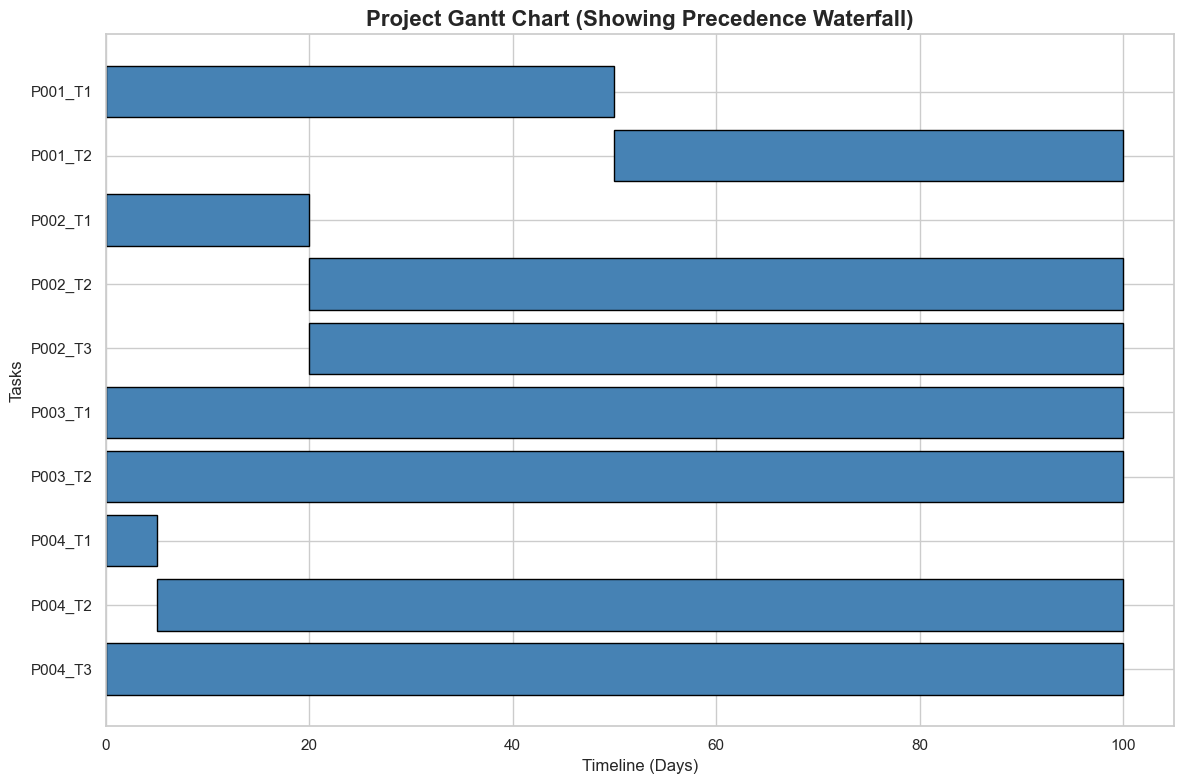

In [2]:
import pandas as pd
import json
from ortools.linear_solver import pywraplp

# ==========================================
# 1. DATA PREPARATION (Assumes Data is Loaded)
# ==========================================
# Make sure your employees_df and tasks_df are loaded here.
# tasks_df must have 'Hours_Needed', 'Task_ID', and 'Predecessors_List'
# employees_df must have 'Employee_ID', 'Hourly_Cost', 'Max_Hours'

# For this script to run, ensure you have parsed your skills into dictionaries:
# employees_df['Specific_Skills_Dict'] 
# tasks_df['Req_Dict']
# tasks_df['Predecessors_List'] 

# ==========================================
# 2. VALID PAIRS & BOTTLENECK RHO (Soft Constraint)
# ==========================================
def calculate_skill_rho(emp_level, task_level):
    if emp_level == 0: return 0.2  
    elif emp_level == task_level: return 1.0  
    elif emp_level > task_level: return 1.5  
    else: return 0.5  

valid_pairs = []
rho_dict = {} 

for _, emp in employees_df.iterrows():
    emp_skills = emp.get('Specific_Skills_Dict', {})
    for _, task in tasks_df.iterrows():
        task_reqs = task.get('Req_Dict', {})
        skill_rhos = []
        missing_skills_count = 0
        
        for skill, req_level in task_reqs.items():
            emp_level = emp_skills.get(skill, 0)
            if emp_level == 0: missing_skills_count += 1
            skill_rhos.append(calculate_skill_rho(emp_level, req_level))
        
        # Must have at least one relevant skill
        if missing_skills_count < len(task_reqs):
            overall_rho = min(skill_rhos)
            pair = (emp['Employee_ID'], task['Task_ID'])
            valid_pairs.append(pair)
            rho_dict[pair] = overall_rho


# ==========================================
# 3. BUILD THE TIME-INDEXED MILP SOLVER
# ==========================================
solver = pywraplp.Solver.CreateSolver('SCIP')

# --- CONFIGURATION PARAMETERS ---
TIME_HORIZON = 100      # Max allowed days for the project to finish (KEEP THIS SMALL FOR TESTING)
HOURS_PER_DAY = 8      # Hours worked in a single day shift
TAU_PENALTY = 20       # Hours lost to context switching per task assignment
M_TIME = TIME_HORIZON + 1 
M_CAP = TIME_HORIZON + 1

# --- DECISION VARIABLES ---
y = {} # Binary: 1 if Employee i is assigned to Task j AT ALL
z = {} # Binary: 1 if Employee i works on Task j on Day t

for (i, j) in valid_pairs:
    y[(i, j)] = solver.BoolVar(f'y_{i}_{j}')
    for t in range(TIME_HORIZON):
        z[(i, j, t)] = solver.BoolVar(f'z_{i}_{j}_{t}')

# Time Variables (Integer Days)
S = {} # Start Day
F = {} # Finish Day
for j in tasks_df['Task_ID']:
    S[j] = solver.IntVar(0, TIME_HORIZON, f'Start_{j}')
    F[j] = solver.IntVar(0, TIME_HORIZON, f'Finish_{j}')

C_max = solver.IntVar(0, TIME_HORIZON, 'Makespan') 

# --- CONSTRAINTS ---

# 1. Assignment Linking: If z=1 on any day, y must be 1. 
# sum(z) <= M * y
for (i, j) in valid_pairs:
    constraint = solver.Constraint(-solver.infinity(), 0, f"Link_y_z_{i}_{j}")
    constraint.SetCoefficient(y[(i, j)], -M_CAP)
    for t in range(TIME_HORIZON):
        constraint.SetCoefficient(z[(i, j, t)], 1)

# 2. Concurrency Limit (NO DOUBLE BOOKING)
# An employee can only work on maximum 1 task per day.
for i in employees_df['Employee_ID']:
    assigned_tasks = [j for (e_id, j) in valid_pairs if e_id == i]
    for t in range(TIME_HORIZON):
        constraint = solver.Constraint(0, 1, f"Concurrency_{i}_{t}")
        for j in assigned_tasks:
            constraint.SetCoefficient(z[(i, j, t)], 1)

# 3. Demand Satisfaction
# sum(z * 8 hours * rho) >= Total Demand Hours
demand_dict = tasks_df.set_index('Task_ID')['Hours_Needed'].to_dict()
for j in tasks_df['Task_ID']:
    capable_employees = [i for (i, t_id) in valid_pairs if t_id == j]
    constraint = solver.Constraint(float(demand_dict[j]), solver.infinity(), f"Demand_{j}")
    for i in capable_employees:
        rho = rho_dict[(i, j)]
        for t in range(TIME_HORIZON):
            constraint.SetCoefficient(z[(i, j, t)], HOURS_PER_DAY * float(rho))

# 4. Total Capacity Limit
# sum(z * 8) + (y * setup_penalty) <= Max_Hours
cap_dict = employees_df.set_index('Employee_ID')['Max_Hours'].to_dict()
for i in employees_df['Employee_ID']:
    assigned_tasks = [j for (e_id, j) in valid_pairs if e_id == i]
    constraint = solver.Constraint(0, float(cap_dict[i]), f"Capacity_{i}")
    for j in assigned_tasks:
        constraint.SetCoefficient(y[(i, j)], TAU_PENALTY)
        for t in range(TIME_HORIZON):
            constraint.SetCoefficient(z[(i, j, t)], HOURS_PER_DAY)

# 5. Link Time Variables (S and F) to Daily Variables (z)
# If z_ijt = 1, then Start <= t, and Finish >= t + 1
for j in tasks_df['Task_ID']:
    capable_employees = [i for (i, t_id) in valid_pairs if t_id == j]
    for i in capable_employees:
        for t in range(TIME_HORIZON):
            # S_j <= t + M(1 - z)  ---> S_j + M * z <= t + M
            s_constraint = solver.Constraint(-solver.infinity(), t + M_TIME, f"Link_S_{i}_{j}_{t}")
            s_constraint.SetCoefficient(S[j], 1)
            s_constraint.SetCoefficient(z[(i, j, t)], M_TIME)
            
            # F_j >= (t + 1) * z  ---> F_j - (t+1)*z >= 0
            f_constraint = solver.Constraint(0, solver.infinity(), f"Link_F_{i}_{j}_{t}")
            f_constraint.SetCoefficient(F[j], 1)
            f_constraint.SetCoefficient(z[(i, j, t)], -(t + 1))

# 6. Precedence Constraints
for _, task in tasks_df.iterrows():
    j = task['Task_ID']
    predecessors = task.get('Predecessors_List', [])
    for p in predecessors:
        constraint = solver.Constraint(0, solver.infinity(), f"Precedence_{p}_to_{j}")
        constraint.SetCoefficient(S[j], 1)
        constraint.SetCoefficient(F[p], -1)

# 7. Makespan Tracker
for j in tasks_df['Task_ID']:
    constraint = solver.Constraint(0, solver.infinity(), f"Makespan_{j}")
    constraint.SetCoefficient(C_max, 1)
    constraint.SetCoefficient(F[j], -1)

# --- OBJECTIVE FUNCTION ---
cost_dict = employees_df.set_index('Employee_ID')['Hourly_Cost'].to_dict()
objective = solver.Objective()

# Financial Cost (Wages for daily work + Wages for Setup Time)
for (i, j) in valid_pairs:
    wage = float(cost_dict[i])
    objective.SetCoefficient(y[(i, j)], wage * TAU_PENALTY)
    for t in range(TIME_HORIZON):
        objective.SetCoefficient(z[(i, j, t)], wage * HOURS_PER_DAY)

# Time Cost (Weight penalty for extending Makespan)
TIME_WEIGHT_PENALTY = 500  
objective.SetCoefficient(C_max, TIME_WEIGHT_PENALTY)

objective.SetMinimization()


# ==========================================
# 4. SOLVE & EXTRACT
# ==========================================
print(f"\nSolving Time-Indexed MILP model with Horizon = {TIME_HORIZON} days...")
print("This may take a while depending on data size...")

status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    print(f"\n✅ Status: OPTIMAL")
    print(f"💰 Total Objective Value: ${solver.Objective().Value():,.2f}")
    print(f"⏱️ Total Project Makespan: {C_max.solution_value():.0f} Days")
    
    # Extract Task Schedule
    schedule_data = []
    for j in tasks_df['Task_ID']:
        schedule_data.append({
            'Task_ID': j,
            'Employee_ID': next((i for (i, t_id) in valid_pairs if t_id == j and y[(i, j)].solution_value() > 0), 'Unassigned'),
            'Start_Day': S[j].solution_value(),
            'Finish_Day': F[j].solution_value(),
            'Duration_Days': F[j].solution_value() - S[j].solution_value()
        })
    schedule_df = pd.DataFrame(schedule_data).sort_values(by='Start_Day')
    print("\n--- Project Schedule ---")
    display(schedule_df)
    
else:
    print(f"Solver failed. Status: {status}")
    print("If status is INFEASIBLE, your TIME_HORIZON might be too short to fit all tasks, or capacity is too low.")

# ==========================================
# 5. GANTT CHART VISUALIZATION (CORRECTED)
# ==========================================
if status == pywraplp.Solver.OPTIMAL:
    sns.set_theme(style="whitegrid")
    
    # FIX: Instead of taking the first 20 tasks of the whole dataset, 
    # let's select a few specific projects that have clear dependencies to prove it works.
    projects_to_show = ['P001_', 'P002_', 'P003_','P004_', 'P005_', 'P006_', 'P007_', 'P008_', 'P009_', 'P010_', 'P011_', 'P012_', 'P013_']  # Adjust as needed based on your Task_ID patterns
    
    # Filter the schedule to only show these projects
    plot_df = schedule_df[schedule_df['Task_ID'].str.contains('|'.join(projects_to_show))]
    
    # Sort backwards by Task_ID so they cascade nicely from top to bottom
    plot_df = plot_df.sort_values(by=['Task_ID'], ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Draw horizontal bars for each task
    for i, row in plot_df.iterrows():
        ax.barh(row['Task_ID'], row['Duration_Days'], left=row['Start_Day'], color='steelblue', edgecolor='black')

    plt.title('Project Gantt Chart (Showing Precedence Waterfall)', fontsize=16, fontweight='bold')
    plt.xlabel('Timeline (Days)', fontsize=12)
    plt.ylabel('Tasks', fontsize=12)
    plt.tight_layout()

    gantt_path = f"{EXPORT_PATH}/gantt_chart_fixed.png"
    plt.savefig(gantt_path, dpi=300)
    print(f"\n📊 Saved Corrected Gantt Chart to: {gantt_path}")
    plt.show()


Generating Utilization Plots...
📊 Saved Resource Heatmap to: 2026-06-16_21-26-28/utilization_heatmap.png


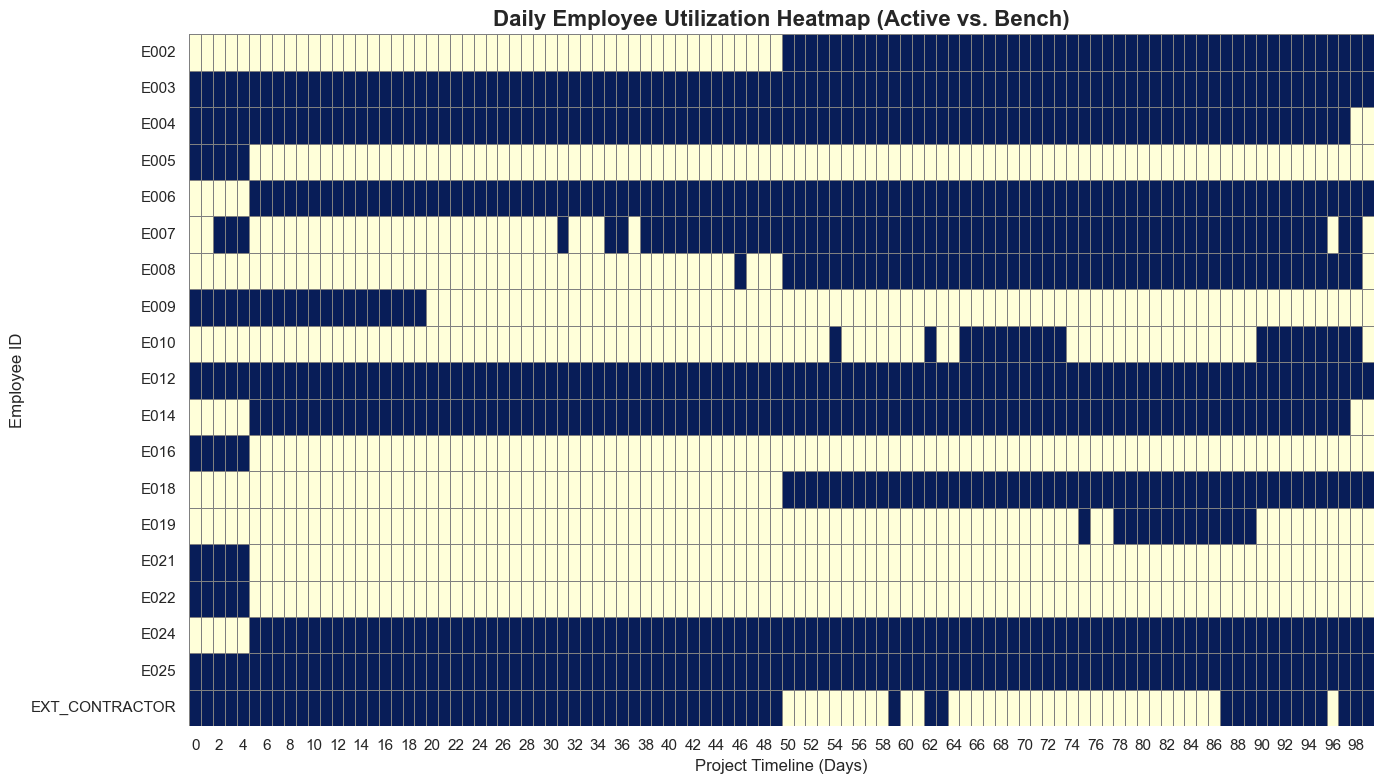

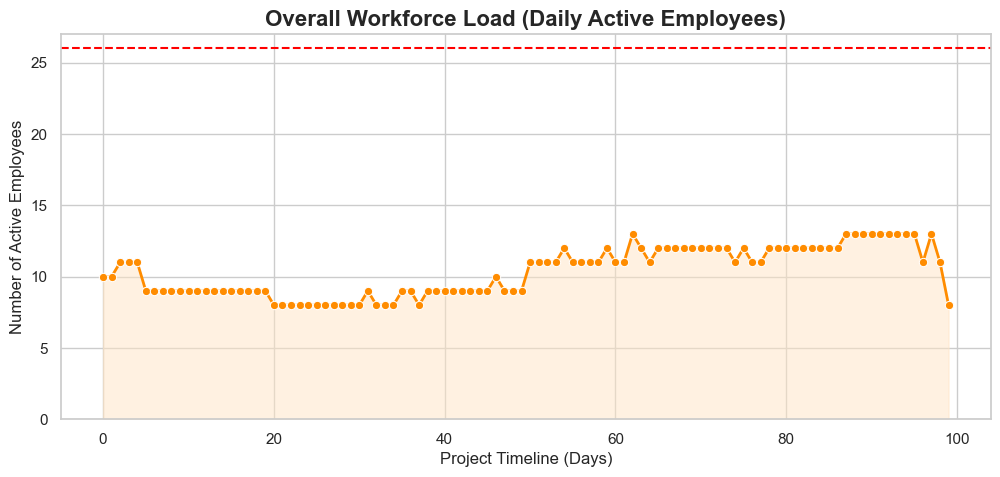

In [3]:
if status == pywraplp.Solver.OPTIMAL:
    print("\nGenerating Utilization Plots...")
    
    # Extract every single day an employee is working
    active_days = []
    for (i, j) in valid_pairs:
        for t in range(TIME_HORIZON):
            if z[(i, j, t)].solution_value() > 0.5:
                active_days.append({
                    'Employee_ID': i, 
                    'Task_ID': j, 
                    'Day': t,
                    'Hours': HOURS_PER_DAY
                })
                
    daily_df = pd.DataFrame(active_days)
    
    # --- PLOT 1: The Resource Heatmap (Schedule Packing) ---
    # This shows EXACTLY what days each employee is busy vs. idle
    plt.figure(figsize=(14, 8))
    
    # Create a pivot table: Rows = Employees, Cols = Days, Values = 1 (Active) or 0 (Idle)
    heatmap_data = daily_df.pivot_table(index='Employee_ID', columns='Day', values='Hours', aggfunc='count', fill_value=0)
    
    # Ensure all days up to Makespan are shown, even if no one is working
    makespan_int = int(C_max.solution_value())
    for day in range(makespan_int):
        if day not in heatmap_data.columns:
            heatmap_data[day] = 0
    heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)

    # Plot the heatmap
    sns.heatmap(heatmap_data, cmap="YlGnBu", cbar=False, linewidths=.5, linecolor='gray')
    plt.title('Daily Employee Utilization Heatmap (Active vs. Bench)', fontsize=16, fontweight='bold')
    plt.xlabel('Project Timeline (Days)', fontsize=12)
    plt.ylabel('Employee ID', fontsize=12)
    plt.tight_layout()
    
    heatmap_path = f"{EXPORT_PATH}/utilization_heatmap.png"
    plt.savefig(heatmap_path, dpi=300)
    print(f"📊 Saved Resource Heatmap to: {heatmap_path}")
    plt.show()

    # --- PLOT 2: Daily Burn Rate (Overall Workforce Load) ---
    # This shows how many employees are active concurrently on any given day
    plt.figure(figsize=(12, 5))
    
    daily_active_count = daily_df.groupby('Day')['Employee_ID'].nunique().reset_index()
    daily_active_count.columns = ['Day', 'Active_Employees']
    
    sns.lineplot(data=daily_active_count, x='Day', y='Active_Employees', marker='o', color='darkorange', linewidth=2)
    plt.fill_between(daily_active_count['Day'], daily_active_count['Active_Employees'], color='bisque', alpha=0.5)
    
    plt.title('Overall Workforce Load (Daily Active Employees)', fontsize=16, fontweight='bold')
    plt.xlabel('Project Timeline (Days)', fontsize=12)
    plt.ylabel('Number of Active Employees', fontsize=12)
    plt.ylim(0, len(employees_df) + 1) # Set max Y to total workforce size
    plt.axhline(y=len(employees_df), color='red', linestyle='--', label='Max Workforce Capacity')
    plt

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ortools.linear_solver import pywraplp

# =====================================================
# FUNCTION: BUILD AND SOLVE MODEL
# =====================================================

def solve_model(
    employees_input,
    tasks_input,
    valid_pairs_input,
    rho_dict_input,
    TIME_WEIGHT_PENALTY=500,
    TAU_PENALTY=20,
    TIME_HORIZON=100,
    HOURS_PER_DAY=8,
    USE_PRECEDENCE=True
):
    solver = pywraplp.Solver.CreateSolver("SCIP")

    if solver is None:
        return None

    M_CAP = TIME_HORIZON + 1
    M_TIME = TIME_HORIZON + 1

    y = {}
    z = {}

    for (i, j) in valid_pairs_input:
        y[(i, j)] = solver.BoolVar(f"y_{i}_{j}")
        for t in range(TIME_HORIZON):
            z[(i, j, t)] = solver.BoolVar(f"z_{i}_{j}_{t}")

    S = {}
    F = {}

    for j in tasks_input["Task_ID"]:
        S[j] = solver.IntVar(0, TIME_HORIZON, f"Start_{j}")
        F[j] = solver.IntVar(0, TIME_HORIZON, f"Finish_{j}")

    C_max = solver.IntVar(0, TIME_HORIZON, "Makespan")

    # 1. Link y and z
    for (i, j) in valid_pairs_input:
        constraint = solver.Constraint(-solver.infinity(), 0)
        constraint.SetCoefficient(y[(i, j)], -M_CAP)
        for t in range(TIME_HORIZON):
            constraint.SetCoefficient(z[(i, j, t)], 1)

    # 2. No double booking
    for i in employees_input["Employee_ID"]:
        assigned_tasks = [j for (e_id, j) in valid_pairs_input if e_id == i]

        for t in range(TIME_HORIZON):
            constraint = solver.Constraint(0, 1)
            for j in assigned_tasks:
                constraint.SetCoefficient(z[(i, j, t)], 1)

    # 3. Demand satisfaction
    demand_dict = tasks_input.set_index("Task_ID")["Hours_Needed"].to_dict()

    for j in tasks_input["Task_ID"]:
        capable_employees = [i for (i, t_id) in valid_pairs_input if t_id == j]

        constraint = solver.Constraint(float(demand_dict[j]), solver.infinity())

        for i in capable_employees:
            rho = rho_dict_input[(i, j)]
            for t in range(TIME_HORIZON):
                constraint.SetCoefficient(z[(i, j, t)], HOURS_PER_DAY * float(rho))

    # 4. Capacity
    cap_dict = employees_input.set_index("Employee_ID")["Max_Hours"].to_dict()

    for i in employees_input["Employee_ID"]:
        assigned_tasks = [j for (e_id, j) in valid_pairs_input if e_id == i]

        constraint = solver.Constraint(0, float(cap_dict[i]))

        for j in assigned_tasks:
            constraint.SetCoefficient(y[(i, j)], TAU_PENALTY)

            for t in range(TIME_HORIZON):
                constraint.SetCoefficient(z[(i, j, t)], HOURS_PER_DAY)

    # 5. Link Start and Finish with z
    for j in tasks_input["Task_ID"]:
        capable_employees = [i for (i, t_id) in valid_pairs_input if t_id == j]

        for i in capable_employees:
            for t in range(TIME_HORIZON):

                s_constraint = solver.Constraint(-solver.infinity(), t + M_TIME)
                s_constraint.SetCoefficient(S[j], 1)
                s_constraint.SetCoefficient(z[(i, j, t)], M_TIME)

                f_constraint = solver.Constraint(0, solver.infinity())
                f_constraint.SetCoefficient(F[j], 1)
                f_constraint.SetCoefficient(z[(i, j, t)], -(t + 1))

    # 6. Precedence
    if USE_PRECEDENCE:
        for _, task in tasks_input.iterrows():
            j = task["Task_ID"]
            predecessors = task.get("Predecessors_List", [])

            for p in predecessors:
                if p in F:
                    constraint = solver.Constraint(0, solver.infinity())
                    constraint.SetCoefficient(S[j], 1)
                    constraint.SetCoefficient(F[p], -1)

    # 7. Makespan
    for j in tasks_input["Task_ID"]:
        constraint = solver.Constraint(0, solver.infinity())
        constraint.SetCoefficient(C_max, 1)
        constraint.SetCoefficient(F[j], -1)

    # Objective
    cost_dict = employees_input.set_index("Employee_ID")["Hourly_Cost"].to_dict()
    objective = solver.Objective()

    for (i, j) in valid_pairs_input:
        wage = float(cost_dict[i])

        objective.SetCoefficient(y[(i, j)], wage * TAU_PENALTY)

        for t in range(TIME_HORIZON):
            objective.SetCoefficient(z[(i, j, t)], wage * HOURS_PER_DAY)

    objective.SetCoefficient(C_max, TIME_WEIGHT_PENALTY)
    objective.SetMinimization()

    status = solver.Solve()

    if status != pywraplp.Solver.OPTIMAL:
        return {
            "Status": "FAILED",
            "Objective": None,
            "Makespan": None,
            "Contractor_Hours": None,
            "Assignments": None,
            "Avg_Tasks_Per_Employee": None
        }

    contractor_hours = 0
    assignments = 0
    tasks_per_employee = {}

    for (i, j) in valid_pairs_input:
        if y[(i, j)].solution_value() > 0.5:
            assignments += 1
            tasks_per_employee[i] = tasks_per_employee.get(i, 0) + 1

        if i == "EXT_CONTRACTOR":
            for t in range(TIME_HORIZON):
                if z[(i, j, t)].solution_value() > 0.5:
                    contractor_hours += HOURS_PER_DAY

    avg_tasks = np.mean(list(tasks_per_employee.values())) if tasks_per_employee else 0

    return {
        "Status": "OPTIMAL",
        "Objective": solver.Objective().Value(),
        "Makespan": C_max.solution_value(),
        "Contractor_Hours": contractor_hours,
        "Assignments": assignments,
        "Avg_Tasks_Per_Employee": avg_tasks
    }

### 1. Time Weight Penalty
In this experiment, we analyze the effect of the project time penalty (TIME_WEIGHT_PENALTY) on the optimal schedule. This parameter determines how strongly the model penalizes long project durations. The analysis allows us to evaluate whether stronger time pressure leads to shorter completion times and how it affects cost and resource utilization.

In [ ]:
# =====================================================
# 1. TIME WEIGHT PENALTY SENSITIVITY
# =====================================================

time_penalties = [0, 500, 10000, 20000, 40000, 60000, 80000]
time_results = []

for val in time_penalties:
    result = solve_model(
        employees_df,
        tasks_df,
        valid_pairs,
        rho_dict,
        TIME_WEIGHT_PENALTY=val,
        TAU_PENALTY=20,
        TIME_HORIZON=100,
        USE_PRECEDENCE=True
    )

    result["TIME_WEIGHT_PENALTY"] = val
    time_results.append(result)

time_sensitivity_df = pd.DataFrame(time_results)
display(time_sensitivity_df)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=time_sensitivity_df,
    x="TIME_WEIGHT_PENALTY",
    y="Makespan",
    marker="o"
)
plt.title("Sensitivity: Time Weight Penalty vs Makespan")
plt.xlabel("Time Weight Penalty")
plt.ylabel("Makespan [days]")
plt.grid(True)
plt.show()

### 2. Context Switching Penalty

In this experiment, we analyze the effect of employee task-switching cost (TAU_PENALTY) on the structure of workforce allocation. The goal is to determine whether higher switching costs lead to a more consolidated schedule and fewer task assignments.

In [ ]:
# =====================================================
# 2. CONTEXT SWITCHING SENSITIVITY
# =====================================================

tau_values = [0, 5, 10, 20, 40, 80]
tau_results = []

for val in tau_values:
    result = solve_model(
        employees_df,
        tasks_df,
        valid_pairs,
        rho_dict,
        TIME_WEIGHT_PENALTY=500,
        TAU_PENALTY=val,
        TIME_HORIZON=100,
        USE_PRECEDENCE=True
    )

    result["TAU_PENALTY"] = val
    tau_results.append(result)

tau_sensitivity_df = pd.DataFrame(tau_results)
display(tau_sensitivity_df)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=tau_sensitivity_df,
    x="TAU_PENALTY",
    y="Assignments",
    marker="o"
)
plt.title("Sensitivity: Context Switching Penalty vs Number of Assignments")
plt.xlabel("Context Switching Penalty")
plt.ylabel("Number of Assignments")
plt.grid(True)
plt.show()

### 3. Capacity Sensitivity

In this experiment, we analyze the effect of workforce availability (Capacity_Multiplier) on contractor usage and overall system performance. The goal is to evaluate whether reducing internal capacity increases outsourcing or extends project duration.

In [ ]:
# =====================================================
# 3. CAPACITY SENSITIVITY
# =====================================================

capacity_multipliers = [0.2, 0.3, 0.4, 0.5, 0.6, 1.0]
capacity_results = []

for mult in capacity_multipliers:
    employees_test = employees_df.copy()
    employees_test["Max_Hours"] = employees_test["Max_Hours"] * mult

    result = solve_model(
        employees_test,
        tasks_df,
        valid_pairs,
        rho_dict,
        TIME_WEIGHT_PENALTY=500,
        TAU_PENALTY=20,
        TIME_HORIZON=100,
        USE_PRECEDENCE=True
    )

    result["Capacity_Multiplier"] = mult
    capacity_results.append(result)

capacity_sensitivity_df = pd.DataFrame(capacity_results)
display(capacity_sensitivity_df)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=capacity_sensitivity_df,
    x="Capacity_Multiplier",
    y="Contractor_Hours",
    marker="o"
)
plt.title("Sensitivity: Capacity Multiplier vs Contractor Hours")
plt.xlabel("Capacity Multiplier")
plt.ylabel("Contractor Hours")
plt.grid(True)
plt.show()

### 4. Precedence Constraints

In this experiment, we analyze the effect of task dependency constraints (precedence constraints) on workforce fragmentation. We compare a schedule without dependencies to the original dependency structure to determine whether enforced task ordering increases the number of assignments and reduces scheduling flexibility.

In [ ]:
# =====================================================
# 4. PRECEDENCE SCENARIOS
# =====================================================

precedence_results = []

scenarios = [
    ("No precedence", False),
    ("Original precedence", True)
]

for scenario_name, use_prec in scenarios:
    result = solve_model(
        employees_df,
        tasks_df,
        valid_pairs,
        rho_dict,
        TIME_WEIGHT_PENALTY=500,
        TAU_PENALTY=20,
        TIME_HORIZON=100,
        USE_PRECEDENCE=use_prec
    )

    result["Scenario"] = scenario_name
    precedence_results.append(result)

precedence_df = pd.DataFrame(precedence_results)
display(precedence_df)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=precedence_df,
    x="Scenario",
    y="Assignments"
)
plt.title("Precedence Scenario vs Makespan")
plt.xlabel("Scenario")
plt.ylabel("Makespan [days]")
plt.grid(True, axis="y")
plt.show()

### Scenario Analysis

W tej części przeprowadzamy analizę scenariuszową, której celem jest zbadanie wpływu jednoczesnych zmian kilku kluczowych parametrów modelu na strukturę rozwiązania oraz wartość funkcji celu. W przeciwieństwie do klasycznej analizy wrażliwości (*one-way sensitivity analysis*), gdzie zmieniany jest pojedynczy parametr przy stałych pozostałych założeniach, tutaj modyfikujemy cały zestaw parametrów jednocześnie. Pozwala to lepiej odwzorować rzeczywiste sytuacje biznesowe, w których zmiany zwykle zachodzą równolegle.

Każdy scenariusz można formalnie zapisać jako:

$$
Scenario_k = (\lambda_k, \tau_k, c_k)
$$

gdzie:

- $\lambda_k$ oznacza wagę kary za całkowity czas realizacji projektu (*TIME Weight Penalty*),
- $\tau_k$ oznacza koszt przełączania pracownika między zadaniami (*Context Switching Penalty*),
- $c_k$ oznacza poziom dostępnej pojemności zasobów (*Capacity Multiplier*).

W modelu parametry te wpływają bezpośrednio na funkcję celu:

$$
Z = Cost_{labor} + Cost_{switching} + \lambda C_{max}
$$

gdzie:

- $Cost_{labor}$ to całkowity koszt pracy,
- $Cost_{switching}$ to koszt przełączania pracowników pomiędzy zadaniami,
- $C_{max}$ to całkowity czas zakończenia całego portfela projektów (*makespan*).

Analiza scenariuszowa pozwala sprawdzić, jak zmienia się optymalne rozwiązanie w zależności od różnych warunków operacyjnych, takich jak presja na szybkie zakończenie projektu, ograniczenia budżetowe lub niedobory kadrowe.

Dla każdego scenariusza model rozwiązywany jest niezależnie, a następnie porównywane są kluczowe wskaźniki:

- wartość funkcji celu,
- całkowity czas realizacji projektu,
- liczba przypisań pracownik–zadanie (*Assignments*),
- wykorzystanie zewnętrznych kontraktorów.

---

#### Base Scenario

$$
Scenario_{base} = (500, 20, 1.0)
$$

Scenariusz bazowy reprezentuje standardowe warunki operacyjne i stanowi punkt odniesienia dla wszystkich pozostałych scenariuszy. Parametry pozostają na poziomie domyślnym, co pozwala ocenić, jak daleko inne scenariusze odchylają się od normalnego funkcjonowania systemu.

---

#### Fast Delivery Scenario

$$
Scenario_{fast} = (5000, 10, 1.0)
$$

W tym scenariuszu zakładamy silną presję na szybkie zakończenie projektu. Osiągamy to poprzez zwiększenie kary za długość realizacji:

$$
\lambda: 500 \rightarrow 5000
$$

oraz jednoczesne obniżenie kosztu przełączania:

$$
\tau: 20 \rightarrow 10
$$

Oznacza to, że model silniej preferuje krótsze harmonogramy i jest bardziej skłonny akceptować większą fragmentację pracy. Scenariusz ten symuluje sytuację, w której priorytetem jest szybkie dostarczenie projektu, nawet kosztem większych wydatków operacyjnych.

---

#### Cost Saving Scenario

$$
Scenario_{cost} = (0, 40, 1.0)
$$

W tym scenariuszu priorytetem jest redukcja kosztów. Presja czasowa zostaje całkowicie usunięta:

$$
\lambda: 500 \rightarrow 0
$$

natomiast koszt przełączania pracowników zostaje zwiększony:

$$
\tau: 20 \rightarrow 40
$$

Taki układ parametrów promuje bardziej stabilną i skonsolidowaną alokację pracy, ograniczając liczbę przypisań i minimalizując koszty operacyjne. Scenariusz ten odzwierciedla strategię nastawioną na maksymalną efektywność kosztową kosztem elastyczności i szybkości realizacji.

---

#### Staff Shortage Scenario

$$
Scenario_{staff} = (500, 20, 0.7)
$$

W tym scenariuszu zachowujemy standardowe priorytety kosztowe i czasowe, ale ograniczamy dostępność zasobów:

$$
c: 1.0 \rightarrow 0.7
$$

Oznacza to, że każdy pracownik dysponuje jedynie 70% swojego standardowego czasu pracy. Scenariusz ten pozwala ocenić odporność modelu na niedobory kadrowe oraz sprawdzić, czy ograniczona dostępność zasobów prowadzi do wzrostu outsourcingu, kosztów lub czasu realizacji.

Dostępność pracowników zostaje ograniczona do 70% standardowego czasu pracy.

In [ ]:
# =====================================================
# 5. SCENARIO ANALYSIS
# =====================================================

scenario_settings = [
    {
        "Scenario": "Base",
        "TIME_WEIGHT_PENALTY": 500,
        "TAU_PENALTY": 20,
        "Capacity_Multiplier": 1.0
    },
    {
        "Scenario": "Fast delivery",
        "TIME_WEIGHT_PENALTY": 5000,
        "TAU_PENALTY": 10,
        "Capacity_Multiplier": 1.0
    },
    {
        "Scenario": "Cost saving",
        "TIME_WEIGHT_PENALTY": 0,
        "TAU_PENALTY": 40,
        "Capacity_Multiplier": 1.0
    },
    {
        "Scenario": "Staff shortage",
        "TIME_WEIGHT_PENALTY": 500,
        "TAU_PENALTY": 20,
        "Capacity_Multiplier": 0.7
    }
]

scenario_results = []

for sc in scenario_settings:
    employees_test = employees_df.copy()
    employees_test["Max_Hours"] = employees_test["Max_Hours"] * sc["Capacity_Multiplier"]

    result = solve_model(
        employees_test,
        tasks_df,
        valid_pairs,
        rho_dict,
        TIME_WEIGHT_PENALTY=sc["TIME_WEIGHT_PENALTY"],
        TAU_PENALTY=sc["TAU_PENALTY"],
        TIME_HORIZON=100,
        USE_PRECEDENCE=True
    )

    result.update(sc)
    scenario_results.append(result)

scenario_df = pd.DataFrame(scenario_results)
display(scenario_df)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=scenario_df,
    x="Scenario",
    y="Makespan"
)
plt.title("Scenario Analysis: Makespan")
plt.xlabel("Scenario")
plt.ylabel("Makespan [days]")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(
    data=scenario_df,
    x="Scenario",
    y="Objective"
)
plt.title("Scenario Analysis: Objective Value")
plt.xlabel("Scenario")
plt.ylabel("Objective")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.show()

### Global Sensitivity Ranking: +20% Parameter Change

W tej części przeprowadzamy globalne porównanie wrażliwości funkcji celu na zmiany wybranych parametrów modelu. Celem tej analizy jest sprawdzenie, który parametr ma największy wpływ na wartość funkcji celu $Z$.

W przeciwieństwie do wcześniejszych analiz, gdzie każdy parametr był testowany w kilku różnych wartościach, tutaj stosujemy jednolitą zmianę procentową. Każdy wybrany parametr zwiększany jest o 20% względem wartości bazowej, a pozostałe parametry pozostają bez zmian.

Dzięki temu można porównać wpływ parametrów w bardziej sprawiedliwy sposób, ponieważ każdy z nich jest modyfikowany o taki sam procent.

Funkcja celu w modelu ma postać:

$$
Z = Cost_{labor} + Cost_{switching} + \lambda C_{max}
$$

gdzie:

- $Cost_{labor}$ oznacza całkowity koszt pracy,
- $Cost_{switching}$ oznacza koszt przełączania pracowników między zadaniami,
- $\lambda$ oznacza karę za czas realizacji projektu,
- $C_{max}$ oznacza całkowity czas zakończenia portfolio projektów.

Najpierw model rozwiązywany jest dla wartości bazowych:

$$
\lambda = 500, \quad \tau = 20, \quad c = 1.0
$$

Otrzymana wartość funkcji celu oznaczana jest jako:

$$
Z_{base}
$$

Następnie każdy parametr jest zwiększany osobno o 20%:

$$
p_{new} = p_{base} \cdot 1.2
$$

Dla każdej zmiany model jest rozwiązywany ponownie, a następnie obliczana jest procentowa zmiana funkcji celu:

$$
\Delta Z\% = \frac{Z_{new} - Z_{base}}{Z_{base}} \cdot 100\%
$$

gdzie:

- $Z_{base}$ to wartość funkcji celu dla scenariusza bazowego,
- $Z_{new}$ to wartość funkcji celu po zwiększeniu danego parametru,
- $\Delta Z\%$ pokazuje, o ile procent zmieniła się funkcja celu.

---

#### Testowane parametry

W analizie porównywane są następujące zmiany:

#### 1. Time Weight Penalty +20%

$$
\lambda: 500 \rightarrow 600
$$

Ten test pokazuje, jak bardzo funkcja celu reaguje na zwiększenie kary za długi czas realizacji projektu. Jeśli $\Delta Z\%$ jest wysokie, oznacza to, że model jest wrażliwy na presję czasową.

---

#### 2. Context Switching Penalty +20%

$$
\tau: 20 \rightarrow 24
$$

Ten test pokazuje, jak zwiększenie kosztu przełączania pracowników między zadaniami wpływa na wartość funkcji celu. Wysoki wzrost $Z$ oznaczałby, że koszt fragmentacji pracy jest istotnym elementem modelu.

---

#### 3. Capacity +20%

$$
c: 1.0 \rightarrow 1.2
$$

Ten test sprawdza, czy zwiększenie dostępności pracowników zmniejsza wartość funkcji celu. Jeśli $Z$ spada, oznacza to, że dodatkowa dostępność zasobów poprawia rozwiązanie. Jeśli zmiana jest niewielka, może to oznaczać, że dostępność pracowników nie jest głównym ograniczeniem.

---

#### 4. Contractor Cost +20%

$$
Cost_{contractor}: 100\% \rightarrow 120\%
$$

Ten test pokazuje, jak wzrost kosztu zewnętrznego kontraktora wpływa na całkowity koszt rozwiązania. Jeśli $Z$ silnie rośnie, oznacza to, że model mocno polega na outsourcingu.

---

#### Interpretacja wyników

Końcowa tabela pokazuje dla każdego parametru:

- wartość bazową,
- wartość po zmianie,
- wartość funkcji celu przed zmianą,
- wartość funkcji celu po zmianie,
- procentową zmianę funkcji celu.

Wykres typu tornado chart przedstawia ranking parametrów według ich wpływu na funkcję celu. Im dłuższy słupek, tym większy wpływ danego parametru na wartość $Z$.

Dodatnie wartości $\Delta Z\%$ oznaczają, że zwiększenie parametru pogorszyło rozwiązanie, czyli zwiększyło wartość funkcji celu. Ujemne wartości oznaczają, że zwiększenie parametru poprawiło rozwiązanie, czyli obniżyło wartość funkcji celu.

Taka analiza pozwala odpowiedzieć na pytanie:

> Który parametr najbardziej wpływa na wartość funkcji celu i powinien być traktowany jako najbardziej krytyczny w modelu?

In [ ]:
# =====================================================
# GLOBAL SENSITIVITY: +20% PARAMETER CHANGE
# =====================================================

BASE_TIME_WEIGHT = 500
BASE_TAU = 20
BASE_CAPACITY = 1.0

CHANGE = 0.20   # +20%

# Base solution
base_result = solve_model(
    employees_df,
    tasks_df,
    valid_pairs,
    rho_dict,
    TIME_WEIGHT_PENALTY=BASE_TIME_WEIGHT,
    TAU_PENALTY=BASE_TAU,
    TIME_HORIZON=100,
    USE_PRECEDENCE=True
)

Z_base = base_result["Objective"]

sensitivity_results = []

# 1. Time weight penalty +20%
result_time = solve_model(
    employees_df,
    tasks_df,
    valid_pairs,
    rho_dict,
    TIME_WEIGHT_PENALTY=BASE_TIME_WEIGHT * (1 + CHANGE),
    TAU_PENALTY=BASE_TAU,
    TIME_HORIZON=200,
    USE_PRECEDENCE=True
)

sensitivity_results.append({
    "Parameter": "TIME_WEIGHT_PENALTY",
    "Base_Value": BASE_TIME_WEIGHT,
    "New_Value": BASE_TIME_WEIGHT * (1 + CHANGE),
    "Z_Base": Z_base,
    "Z_New": result_time["Objective"],
    "Delta_Z_%": ((result_time["Objective"] - Z_base) / Z_base) * 100
})

# 2. Context switching penalty +20%
result_tau = solve_model(
    employees_df,
    tasks_df,
    valid_pairs,
    rho_dict,
    TIME_WEIGHT_PENALTY=BASE_TIME_WEIGHT,
    TAU_PENALTY=BASE_TAU * (1 + CHANGE),
    TIME_HORIZON=200,
    USE_PRECEDENCE=True
)

sensitivity_results.append({
    "Parameter": "TAU_PENALTY",
    "Base_Value": BASE_TAU,
    "New_Value": BASE_TAU * (1 + CHANGE),
    "Z_Base": Z_base,
    "Z_New": result_tau["Objective"],
    "Delta_Z_%": ((result_tau["Objective"] - Z_base) / Z_base) * 100
})

# 3. Capacity +20%
employees_capacity = employees_df.copy()
employees_capacity["Max_Hours"] = employees_capacity["Max_Hours"] * (1 + CHANGE)

result_capacity = solve_model(
    employees_capacity,
    tasks_df,
    valid_pairs,
    rho_dict,
    TIME_WEIGHT_PENALTY=BASE_TIME_WEIGHT,
    TAU_PENALTY=BASE_TAU,
    TIME_HORIZON=200,
    USE_PRECEDENCE=True
)

sensitivity_results.append({
    "Parameter": "Capacity",
    "Base_Value": BASE_CAPACITY,
    "New_Value": BASE_CAPACITY * (1 + CHANGE),
    "Z_Base": Z_base,
    "Z_New": result_capacity["Objective"],
    "Delta_Z_%": ((result_capacity["Objective"] - Z_base) / Z_base) * 100
})

# 4. Contractor cost +20%
employees_contractor = employees_df.copy()
employees_contractor.loc[
    employees_contractor["Employee_ID"] == "EXT_CONTRACTOR",
    "Hourly_Cost"
] *= (1 + CHANGE)

result_contractor = solve_model(
    employees_contractor,
    tasks_df,
    valid_pairs,
    rho_dict,
    TIME_WEIGHT_PENALTY=BASE_TIME_WEIGHT,
    TAU_PENALTY=BASE_TAU,
    TIME_HORIZON=200,
    USE_PRECEDENCE=True
)

sensitivity_results.append({
    "Parameter": "Contractor cost",
    "Base_Value": "original",
    "New_Value": "+20%",
    "Z_Base": Z_base,
    "Z_New": result_contractor["Objective"],
    "Delta_Z_%": ((result_contractor["Objective"] - Z_base) / Z_base) * 100
})

# Results table
global_sensitivity_df = pd.DataFrame(sensitivity_results)
display(global_sensitivity_df)

# Tornado chart
plot_df = global_sensitivity_df.sort_values("Delta_Z_%")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="Delta_Z_%",
    y="Parameter"
)

plt.title("Global Sensitivity Ranking: +20% Parameter Change")
plt.xlabel("Change in Objective Function [%]")
plt.ylabel("Parameter")
plt.grid(True, axis="x", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()